In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from bao import BAOCosmology,BAOLikelihood
from cosmoprimo import Cosmology
import matplotlib.pyplot as plt

In [3]:
from desilike.install import Installer
installer = Installer(user=True)

In [4]:
from desilike.likelihoods.supernovae import Union3SNLikelihood,PantheonPlusSNLikelihood,DESY5SNLikelihood

In [5]:
installer(Union3SNLikelihood)
installer(PantheonPlusSNLikelihood)
installer(DESY5SNLikelihood)

In [7]:
import pandas as pd

df = pd.read_csv("SN_data/DES-Dovekie_HD.csv")

z = df["zHD"].values
mu = df["MU"].values

In [8]:
data = np.load("SN_data/covtot_inv_000.npz")
print(data.files)
print(data["nsn"])
print(data["cov"].shape)

['nsn', 'cov', 'allow_pickle']
[1820]
(1657110,)


In [9]:
nsn = int(data["nsn"][0])
flat = data["cov"]

# create empty matrix
inv_cov = np.zeros((nsn, nsn))

# fill upper triangle
iu = np.triu_indices(nsn)
inv_cov[iu] = flat

# mirror to lower triangle
inv_cov = inv_cov + np.triu(inv_cov, 1).T

print(inv_cov.shape)
cov = np.linalg.inv(inv_cov)

(1820, 1820)


In [16]:
from compressed_sn import rebin_SN
from utils import plot_sn_rebin_with_residual

bins = np.array([0.01, 0.125, 0.235, 0.325, 0.425, 0.625, 0.825, 3])

In [14]:
z_b, mu_b, err_b, cov_b, W = rebin_SN(
    z, mu, cov, bins,
    return_W=True
)

print(z_b.shape)
print(mu_b.shape)
print(cov_b.shape)
print(W.shape)

(7,)
(7,)
(7, 7)
(7, 1820)


In [17]:
np.savez(
    "DES_Dovekey_compressed.npz",
    z_full=z,
    flatdata_binned0=mu_b,
    cov_binned=cov_b,
    ones_binned=np.ones_like(mu_b),
    W=W
)

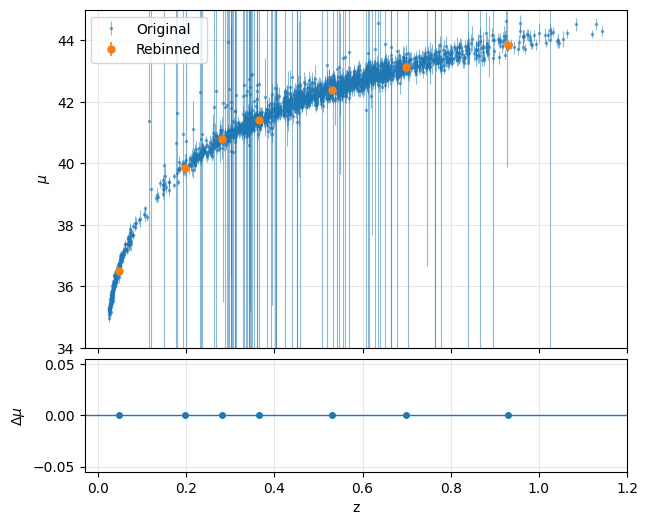

(<Figure size 700x600 with 2 Axes>,
 (<Axes: ylabel='$\\mu$'>, <Axes: xlabel='z', ylabel='$\\Delta\\mu$'>))

In [18]:
plot_sn_rebin_with_residual(
    z,
    mu,
    cov,
    z_b,
    mu_b,
    cov_b,
    W,
    show=True,
    lim_y=(34,45)
)

In [ ]:
data1 = np.load("SN_data/DES_Dovekey_compressed.npz")
flatdata_dovekey = data1['flatdata_binned0']
data2 = np.load("SN_data/desy5_compressed.npz")
flatdata_des = data2['flatdata_binned0']
print(flatdata_des)
print(flatdata_dovekey)
y=np.sqrt(np.diag(data1["cov_binned"]))

[36.56492721 39.91372498 40.80376282 41.42005904 42.3802512  43.1094589
 43.78970224]
[36.49484598 39.8636781  40.78000289 41.42237976 42.39484441 43.12213847
 43.84857484]


<ErrorbarContainer object of 3 artists>

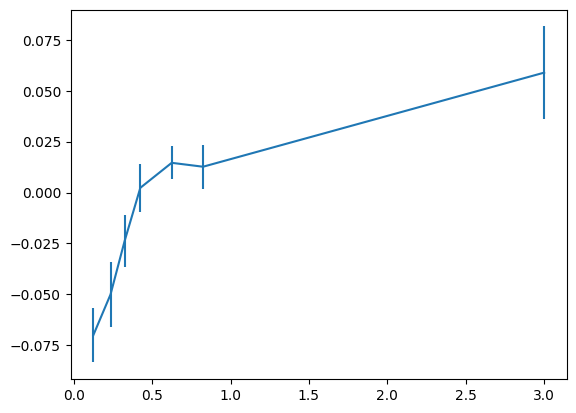

In [40]:
# plt.plot(bins[1:], flatdata_dovekey,".")
plt.errorbar(bins[1:], flatdata_dovekey-flatdata_des, yerr=y)
# plt.plot(bins[1:], flatdata_des,".")

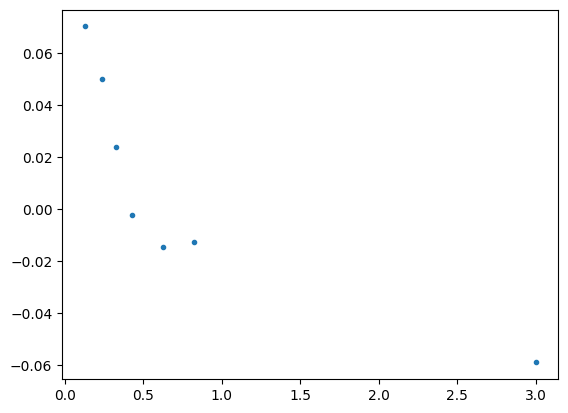

In [31]:
plt.plot(bins[1:],flatdata_des-flatdata_dovekey, ".")

In [21]:
!python run.py \
    --likelihoods SN \
    --model LCDM \
    --sn_likelihood desy5sn \
    --output_label base_lcdm_desy5sn_dovekey_compressed \
    --ncores 8

probe list:  ['SN']
Total parameters: 4
Cosmo params: 3
BAO params: 0
Number of SN datasets: 1
Number of SN nuisance parameters: 1
Iter: 48it [2:18:58, 173.71s/it, beta=1, calls=62464, ESS=7981, logZ=-15.4, logP=-2.48, acc=0.662, steps=3, eff=0.832]    
Sampling complete. Results saved to chains/base_lcdm_desy5sn_dovekey_compressed.txt


# LCDM

DESI2

In [6]:
!python run.py \
    --likelihoods BAO \
    --bao_dataset DESI2 \
    --model LCDM \
    --output_label base_lcdm_desi2 \
    --ncores 8

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


probe list:  ['BAO']
Iter: 17it [37:40, 132.99s/it, beta=1, calls=16128, ESS=795, logZ=-13.2, logP=0.203, acc=0.693, steps=2, eff=0.72]      
Sampling complete. Results saved to chains/base_lcdm_desi2.txt


In [ ]:
!python run.py \
    --likelihoods BAO \
    --bao_dataset DESI2 \
    --model LCDM \
    --output_label base_lcdm_baosys_desi2 \
    --ncores 8 \
    --bao_sys

probe list:  ['BAO']
[[0.01, 0.99], [0.005, 0.1], [0.2, 1], [1, 9]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-08 19:27:21,497:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 44it [14:58, 20.41s/it, beta=1, calls=60160, ESS=7993, logZ=2.64, logP=15, acc=0.881, steps=3, eff=0.832]       
Sampling complete. Results saved to chains/base_lcdm_baosys_desi2.txt


DESI2-SDSS i dont have the desi2-sdss file yet

In [2]:
# !python run.py \
#     --likelihoods BAO-SDSS \
#     --bao_dataset DESI2 \
#     --model LCDM \
#     --output_label base_lcdm_desi2-sdss \
#     --ncores 8

In [4]:
# !python run.py \ 
#     --likelihoods BAO-SDSS \
#     --bao_dataset DESI2 \
#     --model LCDM \
#     --output_label base_lcdm_baosys_desi2_sdss \
#     --ncores 8 \
#     --bao_sys 

DESI2 + CMB

In [ ]:
!python run.py \
    --likelihoods "BAO, CMB" \
    --bao_dataset DESI2 \
    --model LCDM \
    --output_label base_lcdm_desi2_cmb \
    --ncores 8

probe list:  ['BAO', 'CMB']
[[0.01, 0.99], [0.005, 0.1], [0.2, 1]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-08 19:45:31,519:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 57it [14:26, 15.20s/it, beta=1, calls=55040, ESS=7999, logZ=-25.1, logP=-6.48, acc=0.681, steps=4, eff=0.72]        
Sampling complete. Results saved to chains/base_lcdm_desi2_cmb.txt


In [ ]:
!python run.py \
    --likelihoods "BAO, CMB" \
    --bao_dataset DESI2 \
    --model LCDM \
    --output_label base_lcdm_baosys_desi2_cmb \
    --ncores 8 \
    --bao_sys

probe list:  ['BAO', 'CMB']
[[0.01, 0.99], [0.005, 0.1], [0.2, 1], [1, 9]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-08 20:00:09,996:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 58it [21:05, 21.82s/it, beta=1, calls=73984, ESS=8050, logZ=-8.57, logP=8.88, acc=0.852, steps=3, eff=0.832]          
Sampling complete. Results saved to chains/base_lcdm_baosys_desi2_cmb.txt


DESI2 + SN

In [14]:
!python run.py \
    --likelihoods "BAO, SN" \
    --bao_dataset DESI2 \
    --model LCDM \
    --output_label base_lcdm_desi2_union3 \
    --ncores 1

probe list:  ['BAO', 'SN']
[[0.01, 0.99], [0.005, 0.1], [0.2, 1], [-15, -5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-11 01:08:33,139:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 48it [38:55, 48.65s/it, beta=1, calls=59136, ESS=7985, logZ=-31.5, logP=-17, acc=0.88, steps=4, eff=0.832]       
Sampling complete. Results saved to chains/base_lcdm_desi2_union3.txt


In [15]:
!python run.py \
    --likelihoods "BAO, SN" \
    --bao_dataset DESI2 \
    --model LCDM \
    --output_label base_lcdm_baosys_desi2_union3 \
    --ncores 1 \
    --bao_sys

probe list:  ['BAO', 'SN']
[[0.01, 0.99], [0.005, 0.1], [0.2, 1], [1, 9], [-15, -5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-11 01:47:36,615:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 48it [46:50, 58.54s/it, beta=1, calls=68864, ESS=8125, logZ=-15.1, logP=-2.02, acc=0.858, steps=5, eff=0.93]    
Sampling complete. Results saved to chains/base_lcdm_baosys_desi2_union3.txt


In [66]:
!python run.py \
    --likelihoods "SN" \
    --model w0waCDM \
    --output_label base_w0wa_pantheonplus_union3_sys \
    --sn_likelihood "pantheonplus, union3" \
    --sn_sys_individual \
    --ncores 1

probe list:  ['SN']
Total parameters: 9
Cosmo params: 5
BAO params: 0
Number of SN datasets: 2
Number of SN nuisance parameters: 2
Iter: 52it [3:18:23, 228.91s/it, beta=1, calls=96256, ESS=8120, logZ=30.8, logP=40, acc=0.596, steps=6, eff=1]        
Sampling complete. Results saved to chains/base_w0wa_pantheonplus_union3_sys.txt


In [7]:
!python run.py \
    --likelihoods "SN" \
    --model LCDM \
    --output_label base_lcdm_desy5sn_compressed \
    --sn_likelihood desy5sn \
    --ncores 1

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


probe list:  ['SN']
Total parameters: 4
Cosmo params: 3
BAO params: 0
Number of SN datasets: 1
Number of SN nuisance parameters: 1
Iter: 94it [4:24:21, 168.74s/it, beta=1, calls=135424, ESS=19814, logZ=-15.4, logP=-2.6, acc=0.784, steps=3, eff=0.832]     
Sampling complete. Results saved to chains/base_lcdm_desy5sn_compressed.txt


In [7]:
!python run.py \
    --likelihoods "CMB, SN" \
    --model LCDM \
    --output_label base_lcdm_cmb_union3_compressed \
    --sn_likelihood union3 \
    --ncores 1

probe list:  ['CMB', 'SN']
Total parameters: 4
Cosmo params: 3
BAO params: 0
Number of SN datasets: 1
Number of SN nuisance parameters: 1
Iter: 61it [2:49:01, 166.26s/it, beta=1, calls=74240, ESS=8038, logZ=-29.3, logP=-10.7, acc=0.698, steps=7, eff=0.832]       
Sampling complete. Results saved to chains/base_lcdm_cmb_union3_compressed.txt


In [ ]:
!python run.py \
    --likelihoods "BAO, SN" \
    --bao_dataset DESI2 \
    --model w0waCDM \
    --output_label base_w0wa_desi2_pantheonplus_union3_desy5_dovekey_diff_sys_cor \
    --sn_likelihood "pantheonplus, union3, desy5sn" \
    --sn_sys_individual \
    --sn_sys_correlation \
    --ncores 10

probe list:  ['SN']
Total parameters: 9
Cosmo params: 3
BAO params: 0
Number of SN datasets: 3
Number of SN nuisance parameters: 3
Iter: 58it [4:01:13, 249.55s/it, beta=1, calls=107520, ESS=8119, logZ=50.8, logP=64.1, acc=0.606, steps=8, eff=1]         
Sampling complete. Results saved to chains/base_lcdm_pantheonplus_union3_desy5_compressed_sys.txt


In [ ]:
!python run.py \
    --likelihoods "CMB, SN" \
    --model LCDM \
    --output_label base_lcdm_cmb_union3_compressed_systematics \
    --sn_likelihood "union3" \
    --sn_sys_individual \
    --ncores 1

probe list:  ['CMB', 'SN']
Total parameters: 5
Cosmo params: 3
BAO params: 0
Number of SN datasets: 1
Number of SN nuisance parameters: 1
Iter: 60it [3:02:46, 182.78s/it, beta=1, calls=75008, ESS=7974, logZ=-1.35, logP=15.7, acc=0.788, steps=5, eff=0.93]        
Sampling complete. Results saved to chains/base_lcdm_cmb_union3_compressed_systematics.txt


In [8]:
!python run_new.py \
    --likelihoods "SN" \
    --model LCDM \
    --sn_likelihood desy5 \
    --output_label base_lcdm_desy5sn \
    --ncores 10

probe list:  ['SN']
[[0.01, 0.99], [0.005, 0.1], [0.2, 1], [-5, 5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2026-02-05 18:47:08,203:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 95it [39:40, 25.06s/it, beta=1, calls=126208, ESS=19874, logZ=-830, logP=-817, acc=0.778, steps=8, eff=0.832]       
Sampling complete. Results saved to chains/base_lcdm_desy5sn.txt


In [16]:
!python sanity_pp_sn.py \
    --sn_compressed_fn "SN_data/pantheonplus_compressed.npz" \
    --model LCDM \
    --sn_likelihood pantheonplus \
    --output_label base_lcdm_pantheonplus_sanity \
    --output_dir "chains/" \
    --n_total 10000 \
    --ncores 10

Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2026-02-02 10:58:23,369:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 54it [15:07, 16.81s/it, beta=1, calls=76544, ESS=9957, logZ=-710, logP=-697, acc=0.776, steps=3, eff=0.832]         
Done. Saved: chains/base_lcdm_pantheonplus_sanity.txt


DESI2 + CMB + SN

In [18]:
!python run.py \
    --likelihoods "BAO, CMB, SN" \
    --bao_dataset DESI2 \
    --model LCDM \
    --output_label base_lcdm_desi2_cmb_union3 \
    --ncores 1

probe list:  ['BAO', 'CMB', 'SN']
[[0.01, 0.99], [0.005, 0.1], [0.2, 1], [-15, -5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-12 15:47:17,393:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 60it [1:01:16, 61.27s/it, beta=1, calls=84736, ESS=8036, logZ=-42.9, logP=-23.4, acc=0.658, steps=4, eff=0.832]       
Sampling complete. Results saved to chains/base_lcdm_desi2_cmb_union3.txt


In [17]:
!python run.py \
    --likelihoods "BAO, CMB, SN" \
    --bao_dataset DESI2 \
    --model LCDM \
    --output_label base_lcdm_baosys_desi2_cmb_union3 \
    --ncores 1 \
    --bao_sys

probe list:  ['BAO', 'CMB', 'SN']
[[0.01, 0.99], [0.005, 0.1], [0.2, 1], [1, 9], [-15, -5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-11 02:56:43,387:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 61it [46:23, 45.63s/it, beta=1, calls=67840, ESS=8058, logZ=-26.4, logP=-8.22, acc=0.839, steps=3, eff=0.93]         
Sampling complete. Results saved to chains/base_lcdm_baosys_desi2_cmb_union3.txt


## w0waCDM

DESI2

In [ ]:
!python run.py \
    --likelihoods BAO \
    --bao_dataset DESI2 \
    --model w0waCDM \
    --output_label base_w_wa_desi2_test \
    --ncores 8

In [ ]:
!python run.py \
    --likelihoods BAO \
    --bao_dataset DESI2 \
    --model w0waCDM \
    --output_label base_w_wa_baosys_desi2 \
    --ncores 8 \
    --bao_sys

DESI2 + CMB

In [12]:
!python run.py \
    --likelihoods "BAO, CMB" \
    --bao_dataset DESI2 \
    --model w0waCDM \
    --output_label base_w_wa_desi2_cmb_planck \
    --ncores 8

probe list:  ['BAO', 'CMB']
[prior] *WARNING* External prior 'SZ' loaded. Mind that it might not be normalized!
[camb] `camb` module loaded successfully from /home/eleannakolonia/cosmo_project/venv/lib/python3.10/site-packages/camb
[planck_2018_highl_plik.ttteee] `clipy` module loaded successfully from /home/eleannakolonia/cosmo_project/cobaya_packages/code/planck/clipy/clipy
----
clipy_0.15
Checking likelihood '/home/eleannakolonia/cosmo_project/cobaya_packages/data/planck_2018/baseline/plc_3.0/hi_l/plik/plik_rd12_HM_v22b_TTTEEE.clik' on test data. got -1172.47 expected -1172.47 (diff 4.00569e-06)
----
[planck_2018_lensing.clik] `clipy` module loaded successfully from /home/eleannakolonia/cosmo_project/cobaya_packages/code/planck/clipy/clipy
----
clipy_0.15
Checking likelihood '/home/eleannakolonia/cosmo_project/cobaya_packages/data/planck_2018/baseline/plc_3.0/lensing/smicadx12_Dec5_ftl_mv2_ndclpp_p_teb_consext8.clik_lensing' on test data. got -4.42102
----
Iter: 0it [00:00, ?it/s, b

In [8]:
!python run.py \
    --likelihoods "BAO, SN" \
    --bao_dataset DESI2 \
    --model w0waCDM \
    --output_label base_w_wa_desi2_union3 \
    --ncores 1

probe list:  ['BAO', 'SN']
[[-3, 1], [-3, 2], [0.01, 0.99], [0.005, 0.1], [0.2, 1], [-15, -5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-31 11:28:28,701:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 52it [1:19:36, 91.86s/it, beta=1, calls=68608, ESS=8163, logZ=-31, logP=-15.9, acc=0.836, steps=6, eff=1]      
Sampling complete. Results saved to chains/base_w_wa_desi2_union3.txt


In [31]:
!python run.py \
    --likelihoods "BAO, SN" \
    --bao_dataset DESI2 \
    --model w0waCDM \
    --output_label base_w_wa_desi2_union3_sn_sys \
    --ncores 1 \
    --sn_sys

probe list:  ['BAO', 'SN']
[[-3, 1], [-3, 2], [0.01, 0.99], [0.005, 0.1], [0.2, 1], [-15, -5], [1, 5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-11-03 13:44:55,670:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 25it [1:31:25, 219.41s/it, beta=1, calls=34304, ESS=901, logZ=42, logP=56.3, acc=0.655, steps=6, eff=1]       
Sampling complete. Results saved to chains/base_w_wa_desi2_union3_sn_sys.txt


In [ ]:
!python run.py \
    --likelihoods "BAO, SN" \
    --bao_dataset DESI2 \
    --model w0waCDM \
    --output_label base_w_wa_baosys_desi2_union3 \
    --ncores 1 \
    --bao_sys

probe list:  ['BAO', 'SN']
[[-3, 1], [-3, 2], [0.01, 0.99], [0.005, 0.1], [0.2, 1], [1, 9], [-15, -5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-12 19:50:12,098:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 51it [57:50, 68.06s/it, beta=1, calls=75008, ESS=8146, logZ=-15.1, logP=-1.16, acc=0.792, steps=4, eff=1]    
Sampling complete. Results saved to chains/base_w_wa_baosys_desi2_union3.txt


DESI2 + CMB + SN

In [26]:
!python run.py \
    --likelihoods "BAO, CMB, SN" \
    --bao_dataset DESI2 \
    --model w0waCDM \
    --output_label base_w_wa_desi2_cmb_union3 \
    --ncores 1

probe list:  ['BAO', 'CMB', 'SN']
[[-3, 1], [-3, 2], [0.01, 0.99], [0.005, 0.1], [0.2, 1], [-15, -5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-12 20:48:08,675:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 64it [3:20:20, 187.83s/it, beta=1, calls=84992, ESS=8164, logZ=-41.2, logP=-20.5, acc=0.755, steps=5, eff=1]        
Sampling complete. Results saved to chains/base_w_wa_desi2_cmb_union3.txt


In [4]:
!python run.py \
    --likelihoods "BAO, CMB, SN" \
    --bao_dataset DESI2 \
    --model w0waCDM \
    --output_label base_w_wa_desi2_cmb_union3_sn_sys \
    --ncores 1 \
    --sn_sys

probe list:  ['BAO', 'CMB', 'SN']
[[-3, 1], [-3, 2], [0.01, 0.99], [0.005, 0.1], [0.2, 1], [-15, -5], [1, 5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-11-04 13:04:36,307:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 37it [1:00:22, 97.92s/it, beta=1, calls=39936, ESS=777, logZ=31.5, logP=51.2, acc=0.384, steps=3, eff=1]         
Sampling complete. Results saved to chains/base_w_wa_desi2_cmb_union3_sn_sys.txt


In [27]:
!python run.py \
    --likelihoods "BAO, CMB, SN" \
    --bao_dataset DESI2 \
    --model w0waCDM \
    --output_label base_w_wa_baosys_desi2_cmb_union3 \
    --ncores 1 \
    --bao_sys

probe list:  ['BAO', 'CMB', 'SN']
[[-3, 1], [-3, 2], [0.01, 0.99], [0.005, 0.1], [0.2, 1], [1, 9], [-15, -5]]
Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]WARNING:2025-10-13 00:08:35,466:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Iter: 64it [1:10:26, 66.03s/it, beta=1, calls=89344, ESS=8075, logZ=-25.4, logP=-5.68, acc=0.746, steps=4, eff=1]      
Sampling complete. Results saved to chains/base_w_wa_baosys_desi2_cmb_union3.txt


In [37]:
import numpy as np

from desilike import utils
from desilike.cosmo import is_external_cosmo
from desilike.likelihoods.base import BaseLikelihood, BaseGaussianLikelihood 
from desilike.likelihoods.supernovae.base import BaseSNLikelihood

try:
    import jax.numpy as jnp
except Exception:
    jnp = np

class CompressedPantheonPlusSNLikelihood(BaseSNLikelihood):
    """
    Compressed Pantheon+ SN likelihood.

    Loads precomputed compressed arrays from an .npz file:
      - W                (nb, N)
      - z_full           (N,)
      - flatdata_binned0 (nb,)  (data vector with dM/Mb = 0 already applied)
      - cov_binned       (nb, nb)
      - (optional) ones_binned (nb,) = W @ 1

    Likelihood uses:
      flattheory_full(z_full) = 5*log10(DL(z_full)/h) + 25
      flattheory_binned       = W @ flattheory_full
      flatdata_binned         = flatdata_binned0 - dM * (W @ 1)
      cov_binned              fixed
    """
    name = "PantheonPlusSNCompressed"

    def initialize(self, *args, cosmo=None, compressed_fn=None, **kwargs):
        self.cosmo = cosmo

        if compressed_fn is None:
            raise ValueError("Provide compressed_fn pointing to an .npz")

        d = np.load(compressed_fn, allow_pickle=True)

        self.W = np.asarray(d["W"], dtype=float)
        self.z_full = np.asarray(d["z_full"], dtype=float)
        self.flatdata_binned0 = np.asarray(d["flatdata_binned0"], dtype=float)
        self.covariance = np.asarray(d["cov_binned"], dtype=float)

        nb, N = self.W.shape
        if self.z_full.size != N:
            raise ValueError(f"z_full has length {self.z_full.size} but W has N={N} columns.")
        if self.flatdata_binned0.size != nb:
            raise ValueError(f"flatdata_binned0 has length {self.flatdata_binned0.size} but W has nb={nb} rows.")
        if self.covariance.shape != (nb, nb):
            raise ValueError(f"cov_binned has shape {self.covariance.shape} but expected {(nb, nb)}.")

        self.precision = utils.inv(self.covariance)
        self.std = np.sqrt(np.clip(np.diag(self.covariance), 0.0, np.inf))

        if "ones_binned" in d:
            self.ones_binned = np.asarray(d["ones_binned"], dtype=float)
        else:
            self.ones_binned = self.W @ np.ones(N, dtype=float)

        if is_external_cosmo(self.cosmo):
            self.cosmo_requires = {"background": {"luminosity_distance": {"z": self.z_full}}}

    def calculate(self, dM=0.0, Mb=None, sys_coeff=None):
        if Mb is not None:
            dM = Mb

        z = self.z_full

        flattheory_full = 5.0 * jnp.log10(self.cosmo.luminosity_distance(z) / self.cosmo["h"]) + 25.0
        self.flattheory = self.W @ flattheory_full

        self.flatdata = self.flatdata_binned0 - float(dM) * self.ones_binned

        # if sys_coeff is not None:
        #     delta = self.flatdata - self.flattheory
        #     chi2 = delta @ self.precision @ delta

        #     # Systematics rescaling
        #     chi2_sys = chi2/sys_coeff
        #     cov_sys = sys_coeff * self.covariance

        #     self.loglikelihood = -0.5 * (chi2_sys + np.log(np.linalg.det(cov_sys)))

        #     return float(self.loglikelihood)
        # else: 
        #     BaseSNLikelihood.calculate(self)


class CompressedUnion3SNLikelihood(BaseSNLikelihood):
    """
    Compressed Union3 SN likelihood.

    Loads precomputed compressed arrays from an .npz file:
      - W                (nb, N)
      - z_full           (N,)      (Union3 uses 'zcmb')
      - flatdata_binned0 (nb,)     (compressed data vector with dM=0)
      - cov_binned       (nb, nb)
      - (optional) ones_binned (nb,) = W @ 1

    Likelihood uses:
      flattheory_full(z_full) = 5*log10(100 * DL(z_full)) + 25
      flattheory_binned       = W @ flattheory_full
      flatdata_binned         = flatdata_binned0 - dM * (W @ 1)
    """
    name = "Union3SNCompressed"

    def initialize(self, *args, cosmo=None, compressed_fn=None, **kwargs):
        self.cosmo = cosmo

        if compressed_fn is None:
            raise ValueError("Provide compressed_fn pointing to an .npz with W/z_full/flatdata_binned0/cov_binned.")

        d = np.load(compressed_fn, allow_pickle=True)

        self.W = np.asarray(d["W"], dtype=float)
        self.z_full = np.asarray(d["z_full"], dtype=float)
        self.flatdata_binned0 = np.asarray(d["flatdata_binned0"], dtype=float)
        self.covariance = np.asarray(d["cov_binned"], dtype=float)

        nb, N = self.W.shape
        if self.z_full.size != N:
            raise ValueError(f"z_full has length {self.z_full.size} but W has N={N} columns.")
        if self.flatdata_binned0.size != nb:
            raise ValueError(f"flatdata_binned0 has length {self.flatdata_binned0.size} but W has nb={nb} rows.")
        if self.covariance.shape != (nb, nb):
            raise ValueError(f"cov_binned has shape {self.covariance.shape} but expected {(nb, nb)}.")

        self.precision = utils.inv(self.covariance)
        self.std = np.sqrt(np.clip(np.diag(self.covariance), 0.0, np.inf))

        if "ones_binned" in d:
            self.ones_binned = np.asarray(d["ones_binned"], dtype=float)
        else:
            self.ones_binned = self.W @ np.ones(N, dtype=float)

        if is_external_cosmo(self.cosmo):
            self.cosmo_requires = {"background": {"luminosity_distance": {"z": self.z_full}}}

    def calculate(self, dM=0.0, sys_coeff=None):
        z = self.z_full
        
        # Union3 theory: 5*log10(100 * DL) + 25
        # Note: cosmoprimo returns DL in [Mpc/h], so 100*DL is dimensionless H0*d_L
        flattheory_full = 5.0 * jnp.log10(100.0 * self.cosmo.luminosity_distance(z)) + 25.0
        self.flattheory = self.W @ flattheory_full

        self.flatdata = self.flatdata_binned0 - float(dM) * self.ones_binned

        if sys_coeff is not None:
            delta = self.flatdata - self.flattheory
            chi2 = delta @ self.precision @ delta

            # Systematics rescaling
            chi2_sys = chi2/sys_coeff
            cov_sys = sys_coeff * self.covariance

            self.loglikelihood = -0.5 * (chi2_sys + np.log(np.linalg.det(cov_sys)))

            return float(self.loglikelihood)
        else: 
            BaseSNLikelihood.calculate(self)


In [54]:
from scipy.linalg import block_diag, sqrtm

def combine_covariances(A, B, R):
    sqrtA = sqrtm(A)
    sqrtB = sqrtm(B)
    sqrtA = np.real(sqrtA)
    sqrtB = np.real(sqrtB)
    C = R * np.dot(sqrtA, sqrtB)
    M = np.block([[A, C],
                  [C.T, B]])
    return M

class JointCompressedSNLikelihood:

    name = "JointCompressedSN"

    def __init__(self, pantheon_like=None, union_like=None, des_like=None, cosmo=None):
        self.pantheon = pantheon_like
        self.union = union_like
        self.des = des_like
        self.cosmo = cosmo

        # dimensions
        self.n1 = self.pantheon.covariance.shape[0]
        self.n2 = self.union.covariance.shape[0]
        # self.n3 = self.des.covariance.shape[0]

    def calculate(self, dM1=0.0, dM2=0.0, Mb3=0.0, s1=1.0, s2=1.0, s3=1.0, r=0.0):

        # ---- Compute theory + data for each dataset ----
        self.pantheon.calculate(dM=dM1, sys_coeff=None)
        self.union.calculate(dM=dM2, sys_coeff=None)
        # self.desy5.calculate(Mb=Mb3, sys_coeff=None)

        delta1 = self.pantheon.flatdata - self.pantheon.flattheory
        delta2 = self.union.flatdata - self.union.flattheory
        # delta3 = self.des.flatdata - self.des.flattheory

        delta = np.concatenate([delta1, delta2])

        # ---- Build covariance blocks ----
        C1 = self.pantheon.covariance
        C2 = self.union.covariance
        # C3 = self.des.covariance
    
        C11 = s1 * C1
        C22 = s2 * C2
        # C33 = s3 * C3

        # geometric-mean cross block
        sigma1 = sqrtm(C1)
        sigma2 = sqrtm(C2)

        C12 = r * np.matmul(sigma1, sigma2)
        C21 = C12.T

        print(C1, C11.shape, C12.shape, C21.shape, C22.shape)

        # C_full = np.block([
        #     [C11, C12],
        #     [C21, C22]
        # ])
        C_full = combine_covariances(C1, C2, r)

        # ---- Likelihood ----
        sign, logdet = np.linalg.slogdet(C_full)
        if sign <= 0:
            return -np.inf  # not positive definite

        Cinv = np.linalg.inv(C_full)
        chi2 = delta @ Cinv @ delta

        self.loglikelihood = -0.5 * (chi2 + logdet)

        return float(self.loglikelihood)


In [55]:
from cosmoprimo.fiducial import DESI
sn_pantheon = CompressedPantheonPlusSNLikelihood(
                cosmo=DESI(),
                compressed_fn="SN_data/pantheonplus_compressed.npz"
            )
sn_union3 = CompressedUnion3SNLikelihood(
                cosmo=DESI(),
                compressed_fn="SN_data/union3_compressed.npz"
            )
test=JointCompressedSNLikelihood(pantheon_like=sn_pantheon, union_like=sn_union3, cosmo=DESI())


In [59]:
test.calculate(dM1 = -19.17, dM2=-9, s1=1, s2=1, r=-0.1)

[[ 5.03669885e-05 -3.55572197e-06 -9.24784031e-06 -1.14143720e-05
  -1.53025017e-05 -2.01137198e-05 -4.82188163e-05]
 [-3.55572197e-06  1.12025262e-04  2.92367013e-05  2.04677649e-05
   1.36178825e-05  7.70677995e-06  1.95505150e-05]
 [-9.24784031e-06  2.92367013e-05  1.25778359e-04  3.02380947e-05
   3.10592257e-05  3.04592126e-05  3.93794931e-05]
 [-1.14143720e-05  2.04677649e-05  3.02380947e-05  1.59585762e-04
   5.80846625e-05  6.59913583e-05 -3.59069157e-06]
 [-1.53025017e-05  1.36178825e-05  3.10592257e-05  5.80846625e-05
   2.44266458e-04  1.43738949e-04 -8.80562147e-05]
 [-2.01137198e-05  7.70677995e-06  3.04592126e-05  6.59913583e-05
   1.43738949e-04  6.57468548e-04 -2.00372861e-04]
 [-4.82188163e-05  1.95505150e-05  3.93794931e-05 -3.59069157e-06
  -8.80562147e-05 -2.00372861e-04  3.47637732e-03]] (7, 7) (7, 7) (7, 7) (7, 7)


-1670.5394081855288